# Task 1: Data Preprocessing

In this task, the Titanic dataset was cleaned and prepared for machine learning models.

Steps performed:
- Removed unnecessary columns
- Handled missing values
- Encoded categorical variables
- Split dataset into training and testing sets
- Applied feature scaling

In [18]:
import pandas as pd

# Load dataset
df = pd.read_csv("Titanic-Dataset.csv")

# Drop unnecessary columns
df = df.drop(['PassengerId','Name','Ticket','Cabin'], axis=1)

# Handle missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Encode categorical variables
df['Sex'] = df['Sex'].map({'male':0,'female':1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# Split features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Setup complete")
df.head()

Setup complete


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [19]:
df.to_csv("clean_titanic.csv", index=False)

In [20]:
df = pd.read_csv("clean_titanic.csv")

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [22]:
df = pd.read_csv("Titanic-Dataset.csv")

# Drop unnecessary columns
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# Handle missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Encode categorical variables
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [23]:
print("Missing values:")
print(df.isnull().sum())

print("\nDataset info:")
print(df.info())

Missing values:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
dtypes: bool(2), float64(2), int64(5)
memory usage: 50.6 KB
None


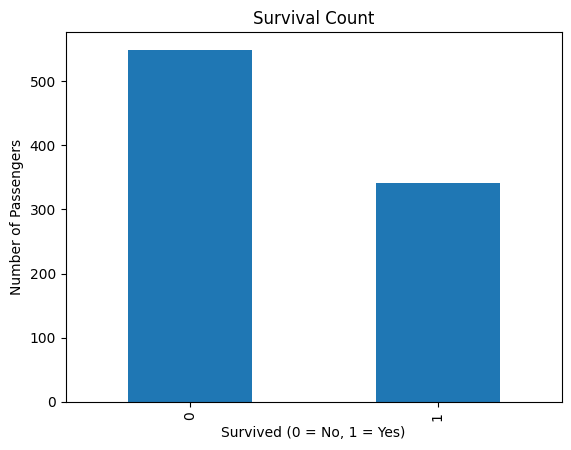

In [24]:
df['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

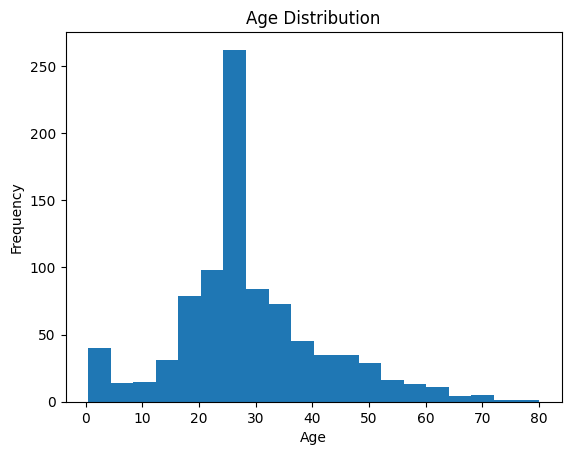

In [25]:
df['Age'].plot(kind='hist', bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [26]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (712, 8)
X_test shape: (179, 8)
y_train shape: (712,)
y_test shape: (179,)


In [29]:
scaler = StandardScaler()

numerical_columns = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']

X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
331,-1.614136,0,1.253641,-0.470722,-0.479342,-0.078684,False,True
733,-0.400551,0,-0.477284,-0.470722,-0.479342,-0.377145,False,True
382,0.813034,0,0.215086,-0.470722,-0.479342,-0.474867,False,True
704,0.813034,0,-0.246494,0.379923,-0.479342,-0.476230,False,True
813,0.813034,1,-1.785093,2.931860,2.048742,-0.025249,False,True


# Task 2: K-Nearest Neighbors (KNN) Classification

In this task, a KNN classifier was trained using the preprocessed Titanic dataset to predict passenger survival.

Steps:
- Loaded the processed dataset
- Trained a KNN model
- Predicted survival outcomes
- Evaluated performance using accuracy, confusion matrix, and classification report

In [30]:
df.to_csv("clean_titanic.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [31]:
df = pd.read_csv("clean_titanic.csv")

In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [33]:
knn = KNeighborsClassifier(n_neighbors=5)

In [34]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [35]:
y_pred = knn.predict(X_test)

In [36]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8044692737430168


In [37]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[90 15]
 [20 54]]


In [38]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



In [39]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create model
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train, y_train)

# Predict on test data
y_pred = knn.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8044692737430168

Confusion Matrix:
[[90 15]
 [20 54]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



# Level 2 – Task 1: Logistic Regression

In this task, a Logistic Regression model was trained on the Titanic dataset to predict passenger survival. The model was evaluated using accuracy, confusion matrix, and classification metrics.

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
log_model = LogisticRegression(max_iter=1000)

In [5]:
import pandas as pd

df = pd.read_csv("Titanic-Dataset.csv")


In [6]:
df = df.drop(['PassengerId','Name','Ticket','Cabin'], axis=1)

In [7]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [8]:
df['Sex'] = df['Sex'].map({'male':0,'female':1})

df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [9]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8100558659217877

Confusion Matrix:
[[90 15]
 [19 55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



# Level 2 – Task 2: Decision Tree Classification

A Decision Tree classifier was trained to predict passenger survival based on the preprocessed Titanic dataset. The model was evaluated using accuracy score, confusion matrix, and classification report.

In [12]:
from sklearn.tree import DecisionTreeClassifier

In [13]:
tree_model = DecisionTreeClassifier(random_state=42)

In [14]:
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [15]:
y_pred_tree = tree_model.predict(X_test)

In [16]:
accuracy = accuracy_score(y_test, y_pred_tree)
print("Decision Tree Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.7877094972067039

Confusion Matrix:
[[86 19]
 [19 55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       105
           1       0.74      0.74      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



## Level 2 Conclusion

Two classification models were implemented: Logistic Regression and Decision Tree. Logistic Regression achieved approximately 81% accuracy, while the Decision Tree model achieved around 79% accuracy on the test dataset.